# Sistemas Parcialmente Fuzzy (P-Fuzzy)

Este caderno exemplifica uma abordagem numérica para resolver um modelo de crescimento logístico

$$P' = \frac{P (100 - P)}{5}, \quad P(0) = 10$$

com sistemas p-fuzzy.

Aqui opta-se pelo uso do framework de lógica fuzzy disponibilizado pelo Scipy, `scikit-fuzzy`, como demonstrado abaixo:

In [2]:
import skfuzzy as fuzz  # Requires networkx
import skfuzzy.control as ctrl
import numpy as np
import matplotlib.pyplot as plt # Might require PyQt6

## Definição dos Conjuntos Fuzzy

A modelagem dos conjuntos fuzzy é baseada nas características qualitativas (pequeno, médio, grande, etc.) de $f(P) = 0.2 \cdot P(100 - P)$ no intervalo $[0, 500]$. Salienta-se que este intervalo deve ser grande o suficiente para conter a imagem de $P(t)$. 

In [11]:
u = np.linspace(0, 500, 500)
v = np.linspace(-500, 500, 500)


# P-fuzzy system instance

pop = ctrl.Antecedent(u, "population")
speed = ctrl.Consequent(v, "increase-rate")

# Population size classification

pop['low'] = fuzz.trimf(pop.universe, [0,25, 50])
pop['lowmid'] = fuzz.trimf(pop.universe, [25, 50, 75])
pop['medium'] = fuzz.trimf(pop.universe, [50, 75, 125])
pop['highmid'] = fuzz.trimf(pop.universe, [75, 125, 375])
pop['high'] = fuzz.trapmf(pop.universe, [375, 450, 500, 500])

# Population increase-rate classification

speed['nhigh'] = fuzz.trapmf(speed.universe, [-500, -500, -375, -250])
speed['nmedium'] = fuzz.trimf(speed.universe, [-375, -250, -125])
speed['nlow'] = fuzz.trimf(speed.universe, [-125, -50, 25])
speed['plow'] = fuzz.trimf(speed.universe, [-25, 50, 125])
speed['pmedium'] = fuzz.trimf(speed.universe, [125, 250, 375])
speed['phigh'] = fuzz.trapmf(speed.universe, [250, 375, 500, 500])

Visto que a solução do PVI tem comportamento distinto para os casos $P > 100$ e $P < 100$, os conjuntos fuzzy definidos para P devem refletir uma mudança em torno de $P = 100$. 

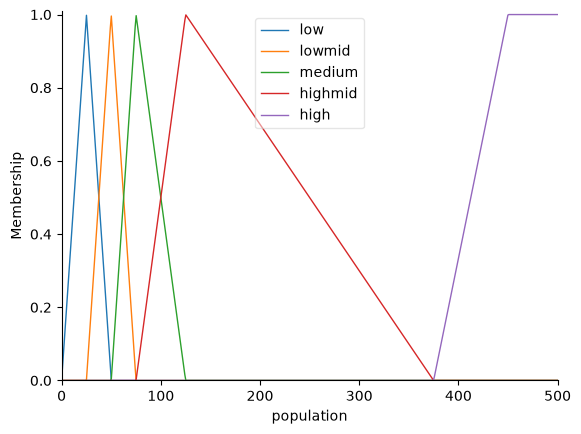

In [12]:
pop.view()

Por outro lado, $P'$ é avaliado simetricamente em relação ao zero.

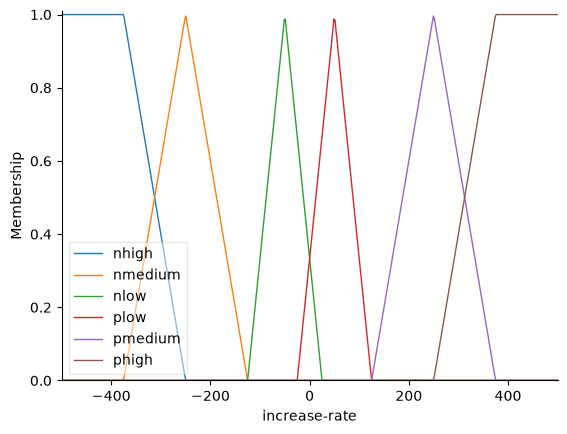

In [13]:
speed.view()

## Sistema de Regras

Avalia-se o "quão grande" $P'$ é dado uma população $P$:

In [14]:
rule0 = ctrl.Rule(antecedent=(pop['low']),
                  consequent=speed['plow'], label='rule low')

rule1 = ctrl.Rule(antecedent=(pop['lowmid']),
                  consequent=speed['phigh'], label='rule low mid')

rule2 = ctrl.Rule(antecedent=(pop['medium']),
                  consequent=speed['plow'], label='rule medium')

rule3 = ctrl.Rule(antecedent=(pop['highmid']),
                  consequent=speed['nlow'], label='rule high mid')

rule4 = ctrl.Rule(antecedent=(pop['high']),
                  consequent=speed['nmedium'], label='rule high')

system = ctrl.ControlSystem(rules=[rule0, rule1, rule2, rule3, rule4])
sim = ctrl.ControlSystemSimulation(system, flush_after_run=21 * 21 + 1)

## Aproximação por Diferenças Finitas

Tome a partição

$$T = \left\{t_0 = 0, t_1 = \frac{t_f}{n + 1}, \ldots, t_{n} = \frac{n t_f}{n + 1}, t_{n + 1} = t_f\right\}$$

e defina $P_i = P(t_i) \, \forall i = 0, \ldots, n + 1$, $h = t_f/(n + 1)$. Então temos que

$$P'(t_i) \approx \frac{P_{i + 1} - P_i}{h},$$

o que nos permite definir a sequência aproximante

$$P_{i + 1} = P_{i} + h \cdot P'{t_i} = P_{i} + h \cdot \hat{f}(P_i),$$

onde $\hat{f}(P)$ é o sistema p-fuzzy que simula $f(P)$.

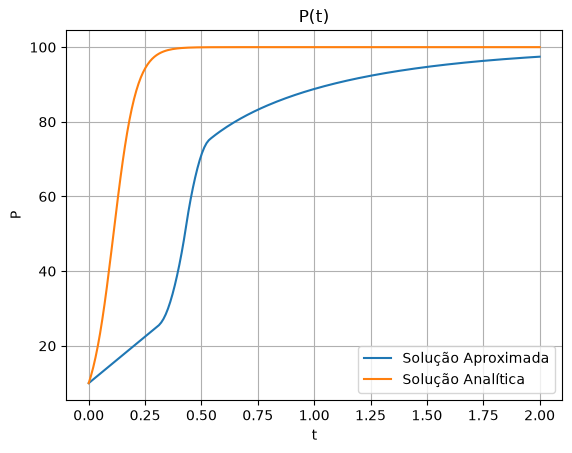

In [23]:
# Finite diference PVI approximation

tf = 2
n = 200
h = tf/n
time = np.linspace(0, tf, n)

p = np.zeros_like(time)
p[0] = 10

for i in range(n - 1):
    sim.input['population'] = p[i]
    sim.compute()
    p[i + 1] = p[i] + h * sim.output['increase-rate']

# Exact solution

sol = lambda t: 100 * np.exp(20 * t) / (9 + np.exp(20 * t))
y = sol(time)

# Plot exact and approximate solution

fig, ax = plt.subplots()
ax.set_xlabel('t')
ax.set_ylabel('P')
ax.set_title('P(t)')
ax.grid(True)
line1, = ax.plot(time, p)
line1.set_label('Solução Aproximada')
line2, = ax.plot(time, y)
line2.set_label('Solução Analítica')
ax.legend()
plt.show()